In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
compiled = pd.read_csv("CombinedClean2.csv")
compiled.head()

,Date,Open,High,Low,Close,Volume,Adj Close,Change,Ratio(%),Value(T),Saham
0,27/03/2020,1874.925171,1983.093931,1707.927787,1711.723182,396812000.0,1711.723182,269.473134,1.868422e+01,6.792323e+11,BMRI
1,30/03/2020,1745.881836,1836.971323,1745.881836,1836.971323,39766600.0,1836.971323,125.248141,7.317079e+00,7.305010e+10,BMRI
2,31/03/2020,1776.244873,1829.380403,1688.950787,1764.858688,208047600.0,1764.858688,-72.112635,-3.925627e+00,3.671746e+11,BMRI
3,01/04/2020,1749.677124,1852.152791,1685.155408,1764.858704,152367000.0,1764.858704,0.000016,9.242681e-07,2.689062e+11,BMRI
4,02/04/2020,1802.812744,1802.812744,1654.792329,1734.495630,132225200.0,1734.495630,-30.363075,-1.720425e+00,2.293440e+11,BMRI


In [3]:
compiled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4969 entries, 0 to 4968
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4969 non-null   object 
 1   Open       4969 non-null   float64
 2   High       4969 non-null   float64
 3   Low        4969 non-null   float64
 4   Close      4969 non-null   float64
 5   Volume     4969 non-null   float64
 6   Adj Close  4969 non-null   float64
 7   Change     4969 non-null   float64
 8   Ratio(%)   4969 non-null   float64
 9   Value(T)   4969 non-null   float64
 10  Saham      4969 non-null   object 
dtypes: float64(9), object(2)
memory usage: 427.2+ KB


In [4]:
compiled.isnull().sum(0)

Date         0
Open         0
High         0
Low          0
Close        0
Volume       0
Adj Close    0
Change       0
Ratio(%)     0
Value(T)     0
Saham        0
dtype: int64

In [5]:
compiled['Date'] = pd.to_datetime(compiled['Date'])

In [6]:
adj_ratio = []

for i, j in zip(compiled['Ratio(%)'], compiled['Change']):
    if j < 0:
        k = -1 * i
        adj_ratio.append(k)
    else:
        adj_ratio.append(i)

In [7]:
compiled.insert(8, 'Adj Ratio', adj_ratio)
compiled.head()

,Date,Open,High,Low,Close,Volume,Adj Close,Change,Adj Ratio,Ratio(%),Value(T),Saham
0,2020-03-27,1874.925171,1983.093931,1707.927787,1711.723182,396812000.0,1711.723182,269.473134,1.868422e+01,1.868422e+01,6.792323e+11,BMRI
1,2020-03-30,1745.881836,1836.971323,1745.881836,1836.971323,39766600.0,1836.971323,125.248141,7.317079e+00,7.317079e+00,7.305010e+10,BMRI
2,2020-03-31,1776.244873,1829.380403,1688.950787,1764.858688,208047600.0,1764.858688,-72.112635,3.925627e+00,-3.925627e+00,3.671746e+11,BMRI
3,2020-04-01,1749.677124,1852.152791,1685.155408,1764.858704,152367000.0,1764.858704,0.000016,9.242681e-07,9.242681e-07,2.689062e+11,BMRI
4,2020-04-02,1802.812744,1802.812744,1654.792329,1734.495630,132225200.0,1734.495630,-30.363075,1.720425e+00,-1.720425e+00,2.293440e+11,BMRI


In [8]:
compiled_list = []
for i in compiled.columns:
    compiled_list.append([i, compiled[i].dtype, compiled[i].isna().sum(), round((compiled[i].isna().sum()/len(compiled[i]))*100,2),
                      compiled[i].nunique(), list(compiled[i].sample(5).drop_duplicates().values)])

compiled_desc = pd.DataFrame(columns = ['Feature Name', 'Type', 'Sum of Null', 'Null Percentage', 'Unique Values', 'Unique  Samples'],data = compiled_list)

In [9]:
compiled_desc

,Feature Name,Type,Sum of Null,Null Percentage,Unique Values,Unique Samples
0,Date,datetime64[ns],0,0.0,1291,"[2023-04-17T00:00:00.000000000, 2020-07-16T00:..."
1,Open,float64,0,0.0,3896,"[41.85979843139648, 22.822349548339844, 44.180..."
2,High,float64,0,0.0,4735,"[2835.751252916124, 38.22285658372568, 2364.76..."
3,Low,float64,0,0.0,4734,"[28.021798033702424, 41.86451482478832, 22.001..."
4,Close,float64,0,0.0,4806,"[43.35452670424552, 2324.6793670026364, 55.580..."
5,Volume,float64,0,0.0,4933,"[1404000.0, 180545000.0, 4949900.0, 3900300.0,..."
6,Adj Close,float64,0,0.0,4806,"[3361.5908691406253, 2786.6900072030144, 5121...."
7,Change,float64,0,0.0,4944,"[6.498881894856368e-07, 1.1586157903545455, 20..."
8,Adj Ratio,float64,0,0.0,4951,"[2.922767901576873, 0.3256301760255374, 0.6763..."
9,Ratio(%),float64,0,0.0,4951,"[0.7692348100730813, 7.787234009361339, 0.2702..."


In [10]:
compiled['Adj Close'] = compiled['Adj Close'].fillna(method = 'bfill')
compiled['Adj Close'].isna().sum()

np.int64(0)

In [11]:
compiled.describe()

,Date,Open,High,Low,Close,Volume,Adj Close,Change,Adj Ratio,Ratio(%),Value(T)
count,4969,4969.000000,4969.000000,4969.000000,4969.000000,4.969000e+03,4969.000000,4969.000000,4969.000000,4969.000000,4.969000e+03
mean,2022-09-22 14:45:37.130207232,962.166538,974.457701,950.378938,962.816539,3.330352e+07,962.816539,0.526469,1.332473,0.097267,1.010477e+11
min,2020-03-26 00:00:00,12.656438,13.030765,12.585813,12.663502,3.090000e+05,12.663502,-454.295582,0.000000,-12.275063,1.063057e+07
25%,2021-06-25 00:00:00,26.312674,26.466503,26.104974,26.288406,3.086300e+06,26.288406,-0.367455,0.451919,-0.869199,7.730026e+07
50%,2022-09-21 00:00:00,41.664551,42.082060,41.322216,41.717183,9.003900e+06,41.717183,0.015846,0.958672,0.050449,3.125943e+08
75%,2023-12-19 00:00:00,72.756187,73.481165,71.699997,72.815775,3.463750e+07,72.815775,0.443957,1.769019,1.027397,1.956511e+09
max,2025-03-24 00:00:00,6769.004883,6859.863882,6723.575195,6769.004757,7.702524e+08,6769.004757,545.154586,18.684217,18.684217,3.165072e+12
std,NaN,1783.982483,1806.117403,1762.819209,1785.036836,5.488256e+07,1785.036836,41.107846,1.361882,1.902919,2.321901e+11


In [12]:
compiled.describe(include = 'object')

,Saham
count,4969
unique,4
top,HSBC
freq,1255


In [13]:
bmri = compiled[compiled['Saham'] == 'BMRI'].sort_values('Date').set_index('Date')
dbs = compiled[compiled['Saham'] == 'DBS'].sort_values('Date').set_index('Date')
hsbc = compiled[compiled['Saham'] == 'HSBC'].sort_values('Date').set_index('Date')
c = compiled[compiled['Saham'] == 'C'].sort_values('Date').set_index('Date')

In [14]:
bmri.head()

,Open,High,Low,Close,Volume,Adj Close,Change,Adj Ratio,Ratio(%),Value(T),Saham
Date,,,,,,,,,,,
2020-03-27,1874.925171,1983.093931,1707.927787,1711.723182,396812000.0,1711.723182,269.473134,1.868422e+01,1.868422e+01,6.792323e+11,BMRI
2020-03-30,1745.881836,1836.971323,1745.881836,1836.971323,39766600.0,1836.971323,125.248141,7.317079e+00,7.317079e+00,7.305010e+10,BMRI
2020-03-31,1776.244873,1829.380403,1688.950787,1764.858688,208047600.0,1764.858688,-72.112635,3.925627e+00,-3.925627e+00,3.671746e+11,BMRI
2020-04-01,1749.677124,1852.152791,1685.155408,1764.858704,152367000.0,1764.858704,0.000016,9.242681e-07,9.242681e-07,2.689062e+11,BMRI
2020-04-02,1802.812744,1802.812744,1654.792329,1734.495630,132225200.0,1734.495630,-30.363075,1.720425e+00,-1.720425e+00,2.293440e+11,BMRI


In [15]:
compiled_Adj_Close = pd.concat([bmri['Adj Close'].iloc[-242:], dbs['Adj Close'].iloc[-242:], hsbc['Adj Close'].iloc[-242:], c['Adj Close'].iloc[-242:]], axis = 1, keys = ['BMRI', 'DBS', 'HSBC', 'C'])
compiled_Adj_Close_sum = compiled_Adj_Close.sum().tolist()
compiled_Adj_Close_sum

[1386921.1976545467, 9269.146893335528, 10816.669881392732, 15891.199253638333]

In [16]:
compiled_Close = pd.concat([bmri['Close'].iloc[-242:], dbs['Close'].iloc[-242:], hsbc['Close'].iloc[-242:], c['Close'].iloc[-242:]], axis = 1, keys = ['BMRI', 'DBS', 'HSBC', 'C'])
compiled_Close_sum = compiled_Close.sum().tolist()
compiled_Close_sum

[1386921.1976545467, 9269.146893335528, 10816.669881392732, 15891.199253638333]

In [17]:
compare_ratio = []
for i, j in zip(compiled_Adj_Close_sum, compiled_Close_sum):
    diff = round((i-j)/j, 5)
    compare_ratio.append(diff)
                         
compare_ratio

[0.0, 0.0, 0.0, 0.0]

In [18]:
compare = {'Adj Close Sum' : compiled_Close_sum, 'Close Sum': compiled_Close_sum, 'Diff' : compare_ratio}
compare_price = pd.DataFrame.from_dict(compare, orient='index',columns = ['BMRI', 'DBS', 'HSBC', 'C'])
compare_price 

,BMRI,DBS,HSBC,C
Adj Close Sum,1.386921e+06,9269.146893,10816.669881,15891.199254
Close Sum,1.386921e+06,9269.146893,10816.669881,15891.199254
Diff,0.000000e+00,0.000000,0.000000,0.000000


In [19]:
compiled_liquid = compiled[['Volume', 'Saham']].groupby('Saham', as_index = False).sum().sort_values('Volume', ascending = False)
compiled_liquid

,Saham,Volume
0,BMRI,1.317902e+11
1,C,2.461739e+10
2,DBS,5.987574e+09
3,HSBC,3.090009e+09


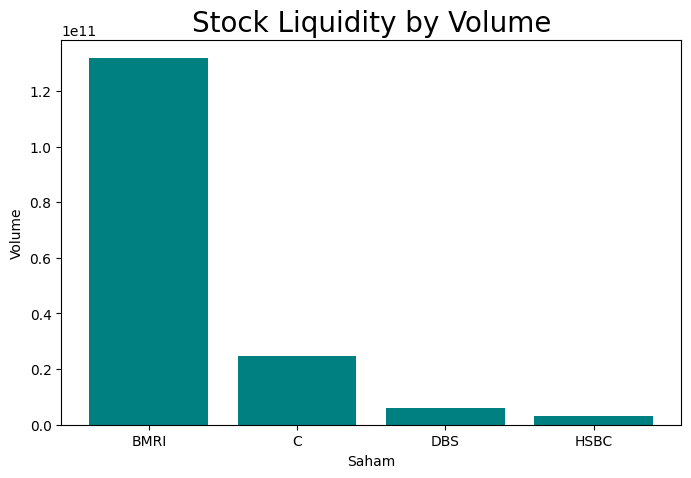

In [20]:

plt.figure(figsize = (8,5))
plt.bar(compiled_liquid['Saham'], compiled_liquid['Volume'], color = 'teal')
plt.xlabel('Saham')
plt.ylabel('Volume')
plt.title('Stock Liquidity by Volume', size = 20)

plt.savefig('Stock Liquidity.png')
plt.show()

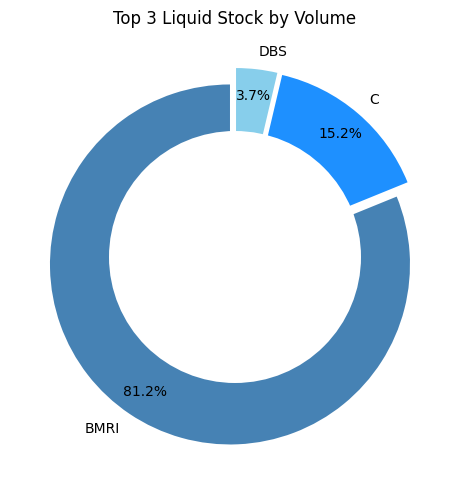

In [21]:
labels = compiled_liquid['Saham'].head(3)
sizes = compiled_liquid['Volume'].head(3)
colors = ['steelblue', 'dodgerblue', 'skyblue']
explode = (0.05, 0.05, 0.05)
plt.pie(sizes, colors = colors, labels = labels, autopct = '%1.1f%%', startangle = 90, pctdistance = 0.85, explode = explode)
centre_circle = plt.Circle((0,0), 0.70,fc = 'white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.tight_layout()
plt.title('Top 3 Liquid Stock by Volume')
plt.savefig('Top 3 Liquid.png', bbox_inches='tight')
plt.show()

In [22]:
compiled_non_liquid = compiled[['Volume', 'Saham']][compiled['Volume'] == 0].groupby('Saham', as_index = False).count().sort_values('Volume', ascending = False)
compiled_non_liquid

,Saham,Volume


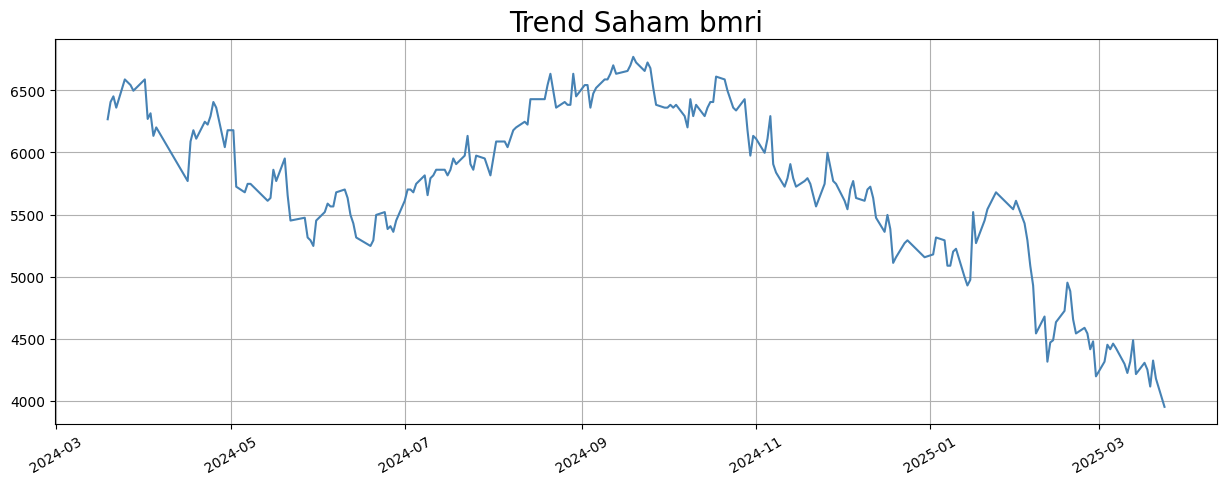

In [23]:
plt.figure(figsize = (15,5))
plt.plot(bmri['Close'].iloc[-242:], color = 'steelblue')
plt.title('Trend Saham bmri', size = 20)
plt.xticks(rotation = 30)
plt.grid()
plt.show()

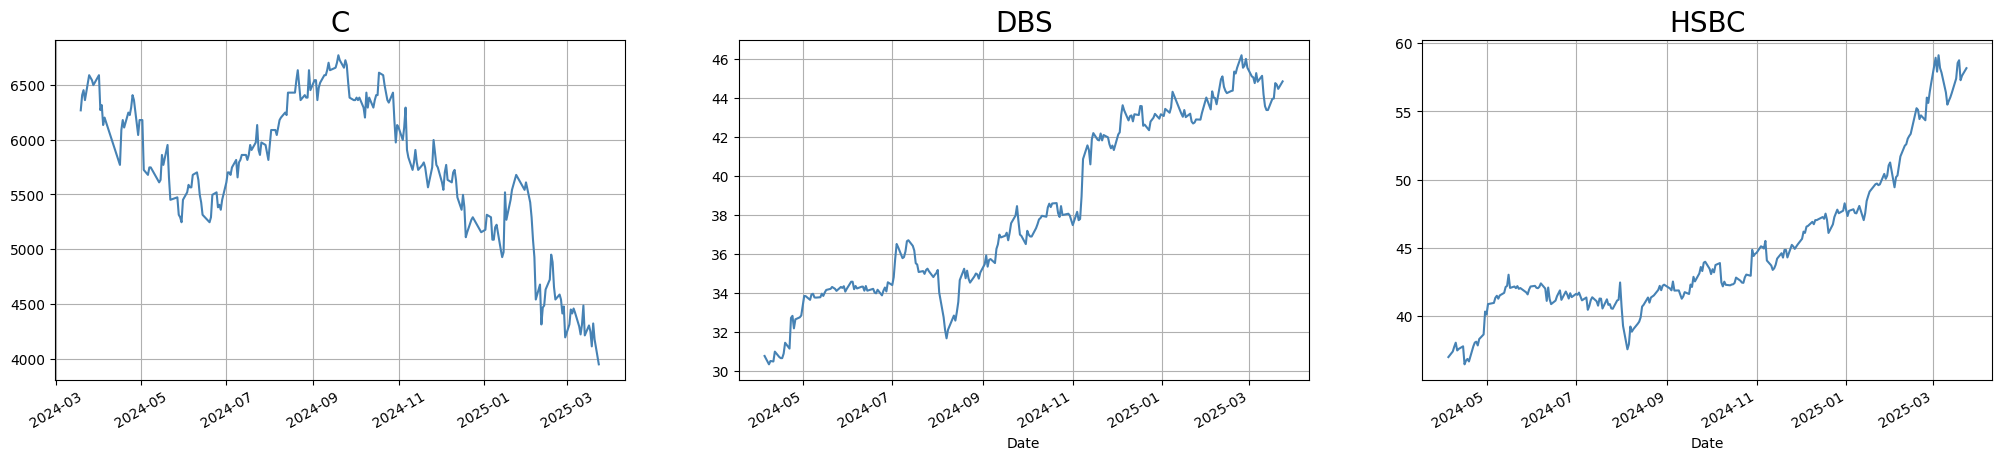

In [24]:
plt.figure(figsize = (25,5))
plt.subplot(131)
plt.plot(bmri['Close'].iloc[-242:], color = 'steelblue')
plt.title('C', size = 20)
plt.xticks(rotation = 30)
plt.grid()

plt.subplot(132)
dbs['Close'].iloc[-242:].plot(color = 'steelblue')
plt.title('DBS', size = 20)
plt.xticks(rotation = 30)
plt.grid()

plt.subplot(133)
hsbc['Close'].iloc[-242:].plot(color = 'steelblue')
plt.title('HSBC', size = 20)
plt.xticks(rotation = 30)
plt.grid()

plt.savefig(' DBS HSBC C.png')
plt.show() 

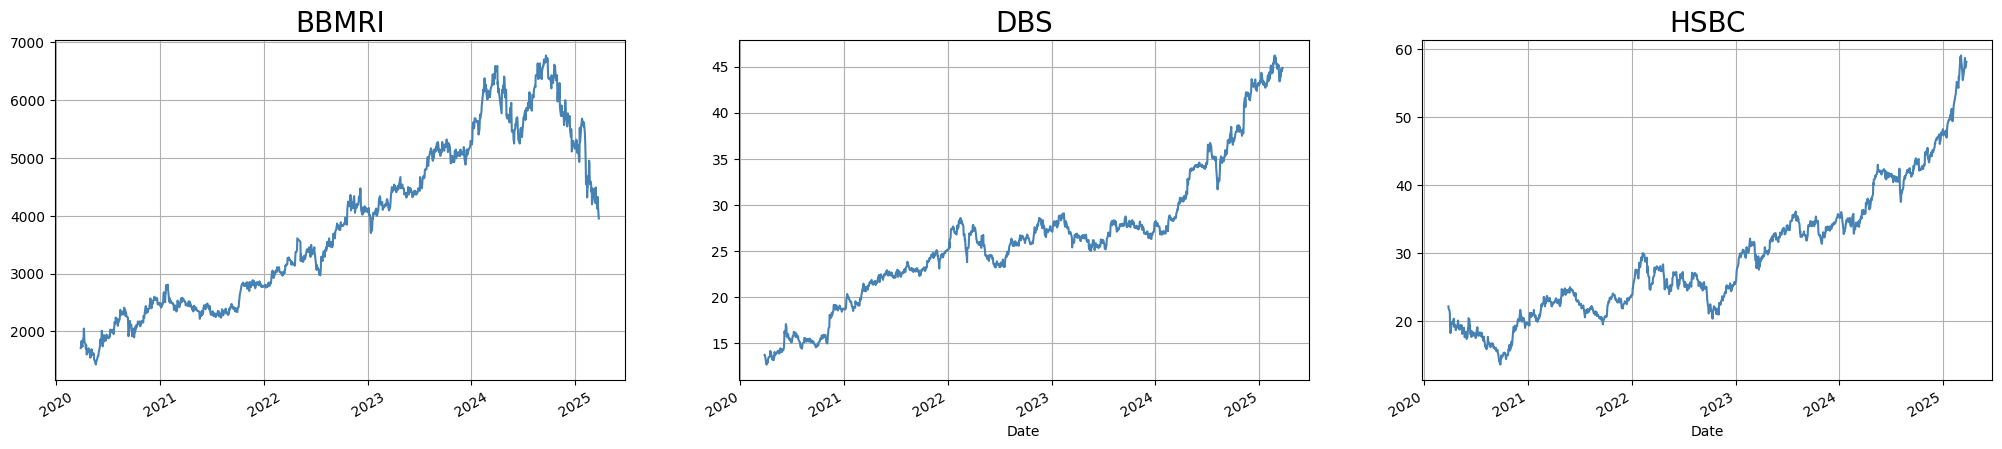

In [25]:

plt.figure(figsize = (25,5))
plt.subplot(131)
plt.plot(bmri['Close'], color = 'steelblue')
plt.title('BBMRI', size = 20)
plt.xticks(rotation = 30)
plt.grid()

plt.subplot(132)
dbs['Close'].plot(color = 'steelblue')
plt.title('DBS', size = 20)
plt.xticks(rotation = 30)
plt.grid()

plt.subplot(133)
hsbc['Close'].plot(color = 'steelblue')
plt.title('HSBC', size = 20)
plt.xticks(rotation = 30)
plt.grid()

plt.savefig('BBMRI DBS HSBC  All.png')
plt.show() 

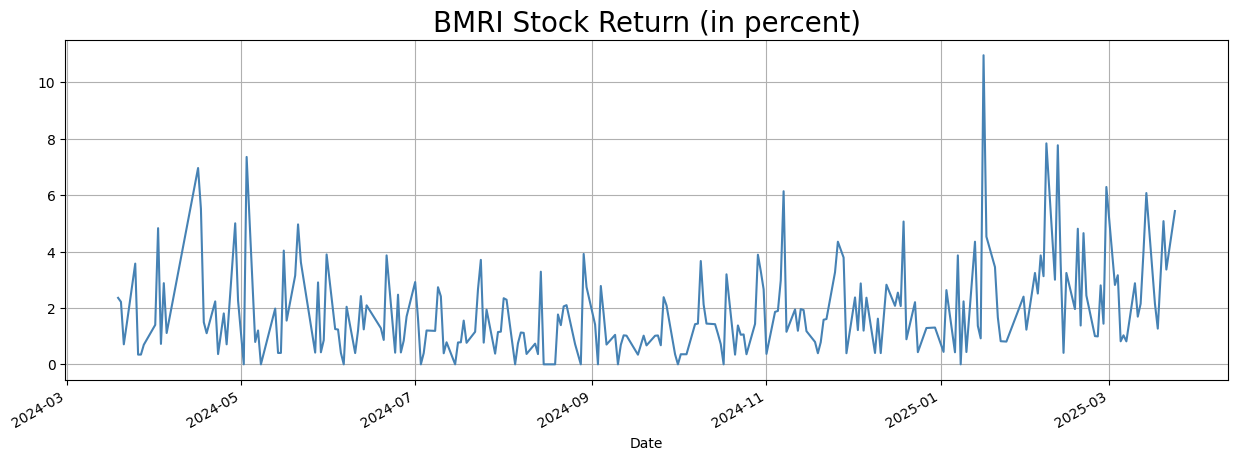

In [26]:
plt.figure(figsize = (15,5))
bmri['Adj Ratio'].iloc[-242:].plot(color = 'steelblue')
plt.title('BMRI Stock Return (in percent)', size = 20)
plt.xticks(rotation = 30)
plt.grid()

plt.savefig('BMRI Return.png')
plt.show()

In [27]:
bmri['Adj Ratio'].describe().to_frame().transpose()

,count,mean,std,min,25%,50%,75%,max
Adj Ratio,1206.0,1.595599,1.558969,0.0,0.511214,1.192848,2.1264,18.684217


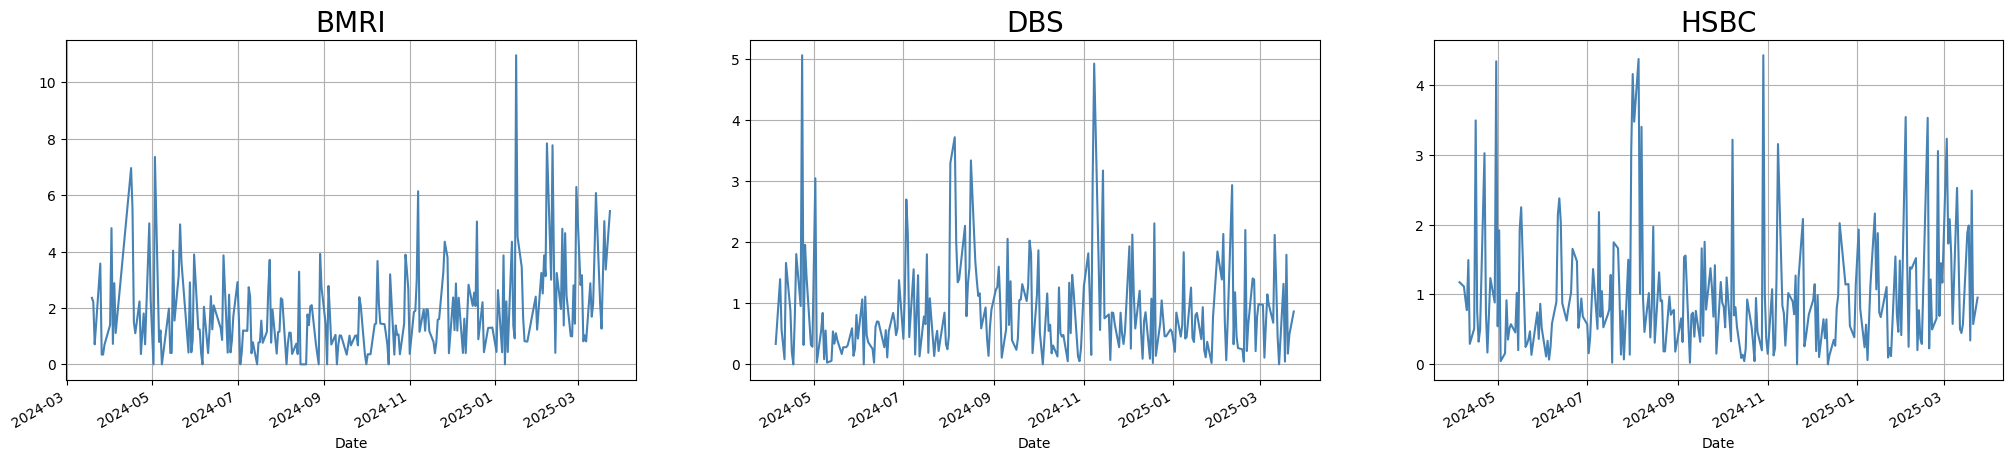

In [28]:

plt.figure(figsize = (25,5))
plt.subplot(131)
bmri['Adj Ratio'].iloc[-242:].plot(color = 'steelblue')
plt.title('BMRI', size = 20)
plt.xticks(rotation = 30)
plt.grid()

plt.subplot(132)
dbs['Adj Ratio'].iloc[-242:].plot(color = 'steelblue')
plt.title('DBS', size = 20)
plt.xticks(rotation = 30)
plt.grid()

plt.subplot(133)
hsbc['Adj Ratio'].iloc[-242:].plot(color = 'steelblue')
plt.title('HSBC', size = 20)
plt.xticks(rotation = 30)
plt.grid()

plt.savefig('BMRI DBS HSBC Ratio.png')
plt.show() 

In [29]:
def trend(x):
  if x > -0.05 and x <= 0.05:
    return 'Slight or No change'
  elif x > 0.05 and x <= 0.1:
    return 'Slight Positive'
  elif x > -0.1 and x <= -0.05:
    return 'Slight Negative'
  elif x > 0.1 and x <= 0.3:
    return 'Positive'
  elif x > -0.3 and x <= -0.1:
    return 'Negative'
  elif x > 0.3 and x <= 0.7:
    return 'Among top gainers'
  elif x > -0.7 and x <= -0.3:
    return 'Among top losers'
  elif x > 0.7:
    return 'Bull run'
  elif x <= -0.7:
    return 'Bear drop'

In [30]:
bmri['Trend Category'] = np.zeros(bmri['Adj Ratio'].count())
bmri['Trend Category'] = bmri['Adj Ratio'].apply(lambda x:trend(x))
bmri.head()

,Open,High,Low,Close,Volume,Adj Close,Change,Adj Ratio,Ratio(%),Value(T),Saham,Trend Category
Date,,,,,,,,,,,,
2020-03-27,1874.925171,1983.093931,1707.927787,1711.723182,396812000.0,1711.723182,269.473134,1.868422e+01,1.868422e+01,6.792323e+11,BMRI,Bull run
2020-03-30,1745.881836,1836.971323,1745.881836,1836.971323,39766600.0,1836.971323,125.248141,7.317079e+00,7.317079e+00,7.305010e+10,BMRI,Bull run
2020-03-31,1776.244873,1829.380403,1688.950787,1764.858688,208047600.0,1764.858688,-72.112635,3.925627e+00,-3.925627e+00,3.671746e+11,BMRI,Bull run
2020-04-01,1749.677124,1852.152791,1685.155408,1764.858704,152367000.0,1764.858704,0.000016,9.242681e-07,9.242681e-07,2.689062e+11,BMRI,Slight or No change
2020-04-02,1802.812744,1802.812744,1654.792329,1734.495630,132225200.0,1734.495630,-30.363075,1.720425e+00,-1.720425e+00,2.293440e+11,BMRI,Bull run


In [31]:
bmri_pie = bmri[['Adj Ratio', 'Trend Category']].groupby('Trend Category', as_index = False).count().sort_values('Adj Ratio', ascending = False)
bmri_pie

,Trend Category,Adj Ratio
1,Bull run,862
0,Among top gainers,215
3,Slight or No change,109
2,Positive,20


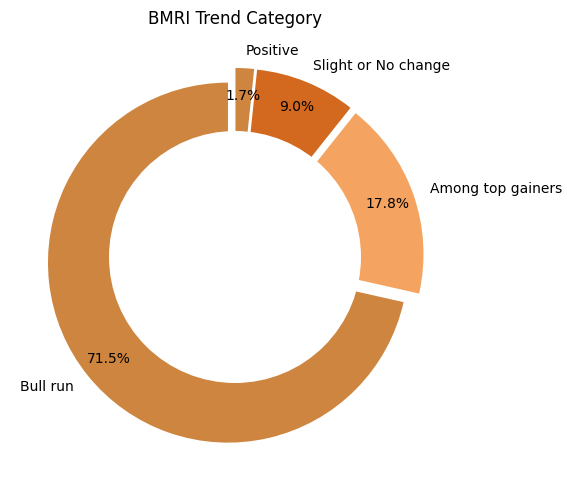

In [32]:
# Pie chart
labels = bmri_pie['Trend Category'].head()
sizes = bmri_pie['Adj Ratio'].head()

# Colors (kamu bisa tambah kalau jumlah data > 3)
colors = ['peru', 'sandybrown', 'chocolate']

# Explode harus sesuai panjang data
explode = [0.05] * len(sizes)

# Pie plot
plt.pie(sizes, colors=colors[:len(sizes)], labels=labels, autopct='%1.1f%%', 
        startangle=90, pctdistance=0.85, explode=explode)

# Draw circle
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Make sure it's a circle
plt.tight_layout()
plt.title('BMRI Trend Category')
plt.savefig('BMRI Trend Category.png', bbox_inches='tight')
plt.show()


In [33]:
dbs['Trend Category'] = np.zeros(dbs['Adj Ratio'].count())
dbs['Trend Category'] = dbs['Adj Ratio'].apply(lambda x:trend(x))
dbs.head()

,Open,High,Low,Close,Volume,Adj Close,Change,Adj Ratio,Ratio(%),Value(T),Saham,Trend Category
Date,,,,,,,,,,,,
2020-03-26,13.461590,13.737037,13.221456,13.715848,10894070.0,13.715848,0.628582,4.803007,4.803007,1.494214e+08,DBS,Bull run
2020-03-27,13.518092,13.857104,13.369774,13.701723,13290310.0,13.701723,-0.014126,0.102989,-0.102989,1.821001e+08,DBS,Positive
2020-03-30,12.924823,13.292087,12.924823,13.179083,9736320.0,13.179083,-0.522640,3.814409,-3.814409,1.283158e+08,DBS,Bull run
2020-03-31,13.115518,13.256772,12.981324,13.023701,12165180.0,13.023701,-0.155382,1.179004,-1.179004,1.584357e+08,DBS,Bull run
2020-04-01,12.818883,13.066078,12.762381,13.023702,7767540.0,13.023702,0.000001,0.000008,0.000008,1.011621e+08,DBS,Slight or No change


In [34]:
dbs_pie = dbs[['Adj Ratio', 'Trend Category']].groupby('Trend Category', as_index = False).count().sort_values('Adj Ratio', ascending = False)
dbs_pie

,Trend Category,Adj Ratio
1,Bull run,622
0,Among top gainers,346
2,Positive,175
4,Slight or No change,62
3,Slight Positive,48


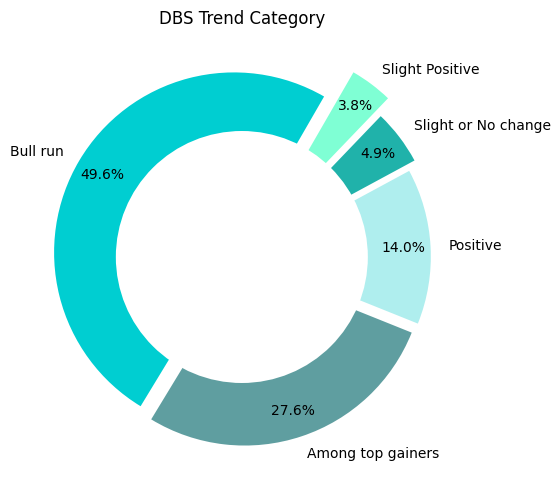

In [35]:

# Pie chart
labels = dbs_pie['Trend Category'].head()
sizes = dbs_pie['Adj Ratio'].head()

#colors
colors = ['darkturquoise', 'cadetblue', 'paleturquoise', 'lightseagreen', 'aquamarine']
#explosion
explode = (0.05, 0.05, 0.05, 0.1, 0.2)
 
plt.pie(sizes, colors = colors, labels = labels, autopct = '%1.1f%%', startangle = 60, pctdistance = 0.85, explode = explode)
#draw circle
centre_circle = plt.Circle((0,0), 0.70,fc = 'white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Equal aspect ratio ensures that pie is drawn as a circle
plt.tight_layout()
plt.title('DBS Trend Category')

plt.savefig('DBS Trend Category.png', bbox_inches='tight')
plt.show()

In [36]:
compiled_ratio = pd.concat([bmri['Adj Ratio'], dbs
['Adj Ratio'], bmri['Adj Ratio'], dbs['Adj Ratio'], hsbc['Adj Ratio'], c['Adj Ratio']], axis = 1, keys = ['BMRI', 'DBS', 'HSBC', 'C'])
compiled_ratio

,BMRI,DBS,HSBC,C
Date,,,,
2020-03-26,NaN,4.803007,NaN,4.803007
2020-03-27,1.868422e+01,0.102989,1.868422e+01,0.102989
2020-03-30,7.317079e+00,3.814409,7.317079e+00,3.814409
2020-03-31,3.925627e+00,1.179004,3.925627e+00,1.179004
2020-04-01,9.242681e-07,0.000008,9.242681e-07,0.000008
...,...,...,...,...
2025-03-18,1.265820e+00,0.044854,1.265820e+00,0.044854
2025-03-19,3.205131e+00,1.793733,3.205131e+00,1.793733
2025-03-20,5.077271e+00,0.176220,5.077271e+00,0.176220


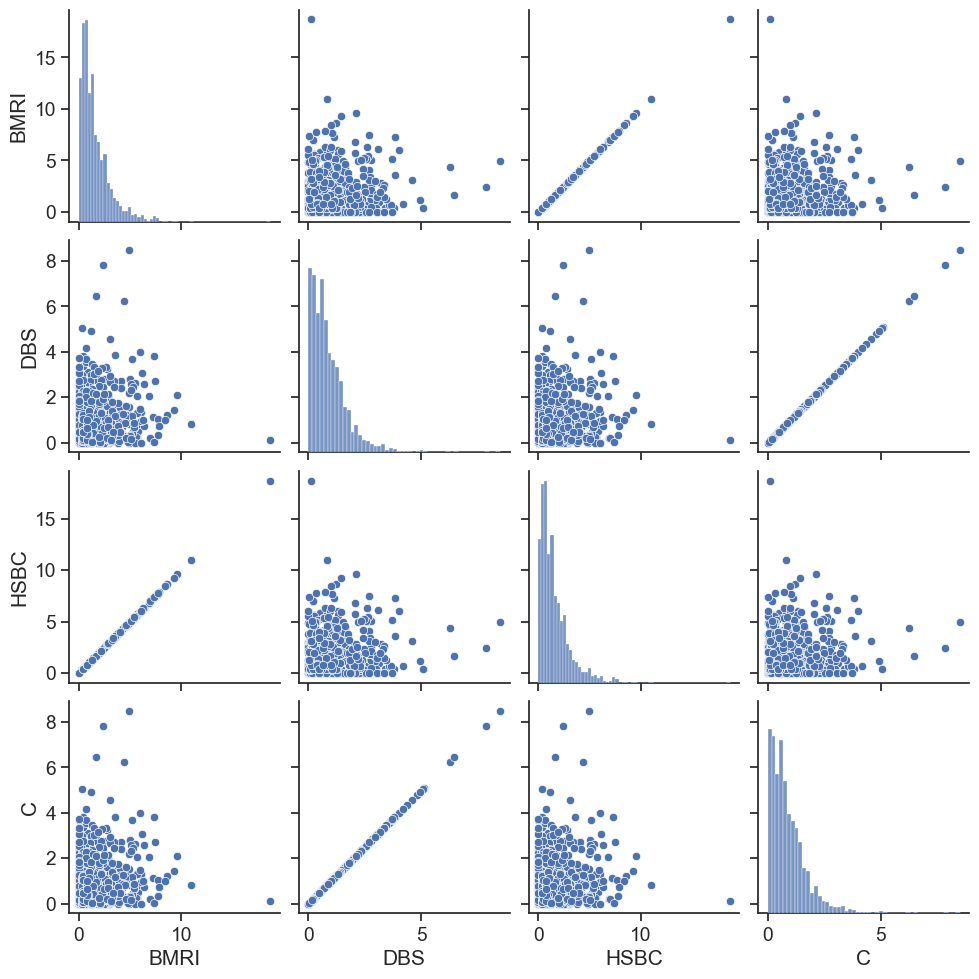

In [37]:
sns.set(style = 'ticks', font_scale = 1.25)
sns.pairplot(compiled_ratio)

plt.show()

In [38]:
for i in compiled_ratio.columns:
    normal, p = stats.normaltest(compiled_ratio[i])
    
    # h0: X comes from normal distribution
    # h1: X does not come from normal distribution
    if p < 0.05:
        print(f'{i} does not come from normal distribution.')
    else:
        print(f'{i} comes from normal distribution.')

BMRI comes from normal distribution.
DBS comes from normal distribution.
HSBC comes from normal distribution.
C comes from normal distribution.


In [39]:
ratio_cor = compiled_ratio.corr(method = 'pearson')
ratio_cor

,BMRI,DBS,HSBC,C
BMRI,1.000000,0.073686,1.000000,0.073686
DBS,0.073686,1.000000,0.073686,1.000000
HSBC,1.000000,0.073686,1.000000,0.073686
C,0.073686,1.000000,0.073686,1.000000


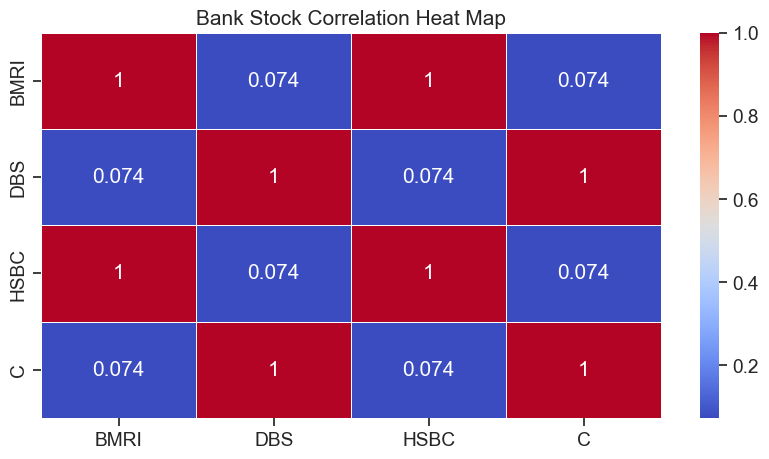

In [40]:
plt.figure(figsize= (10,5))
sns.heatmap(ratio_cor, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title('Bank Stock Correlation Heat Map')

plt.savefig('Stock Corr Heatmap.png')
plt.show()

In [41]:
compiled.to_csv('compiled_clean.csv')

In [42]:
compiled_model = compiled[['Date', 'Saham', 'Close', 'Adj Close', 'Adj Ratio', 'Volume']].copy()
compiled_model['Date'] = pd.to_datetime(compiled_model['Date'])
compiled_model['Year'] = compiled_model['Date'].dt.year
compiled_model['Month'] = compiled_model['Date'].dt.month
compiled_model['Day'] = compiled_model['Date'].dt.day
compiled_model['DayofWeek'] = compiled_model['Date'].dt.dayofweek
compiled_model.sort_values(['Saham', 'Date'], inplace=True)

In [43]:
compiled_model['Return_2y'] = compiled_model.groupby('Saham')['Close'].transform(lambda x: (x.shift(-504) - x) / x)

In [44]:
compiled_model.to_csv('compiled_model_with_return2y.csv', index=False)
compiled_model.head()

,Date,Saham,Close,Adj Close,Adj Ratio,Volume,Year,Month,Day,DayofWeek,Return_2y
0,2020-03-27,BMRI,1711.723182,1711.723182,1.868422e+01,396812000.0,2020,3,27,4,0.969869
1,2020-03-30,BMRI,1836.971323,1836.971323,7.317079e+00,39766600.0,2020,3,30,0,0.835560
2,2020-03-31,BMRI,1764.858688,1764.858688,3.925627e+00,208047600.0,2020,3,31,1,0.922211
3,2020-04-01,BMRI,1764.858704,1764.858704,9.242681e-07,152367000.0,2020,4,1,2,0.928036
4,2020-04-02,BMRI,1734.495630,1734.495630,1.720425e+00,132225200.0,2020,4,2,3,1.080324


In [45]:
bmri_clean = bmri.drop(columns=['Open', 'High', 'Low', 'Adj Close', 'Change', 'Ratio(%)', 'Adj Ratio', 'Volume', 'Value(T)', 'Saham', 'Trend Category'], errors='ignore')
bmri_clean.to_csv('dataBMRI.csv')
bmri_clean

,Close
Date,
2020-03-27,1711.723182
2020-03-30,1836.971323
2020-03-31,1764.858688
2020-04-01,1764.858704
2020-04-02,1734.495630
...,...
2025-03-18,4252.207148
2025-03-19,4115.918344
2025-03-20,4324.894679


In [46]:
dbs_clean = dbs.drop(columns=['Open', 'High', 'Low', 'Adj Close', 'Change', 'Ratio(%)', 'Adj Ratio', 'Volume', 'Value(T)', 'Saham', 'Trend Category'], errors='ignore')
dbs_clean.to_csv('dataDBS.csv')
dbs_clean

,Close
Date,
2020-03-26,13.715848
2020-03-27,13.701723
2020-03-30,13.179083
2020-03-31,13.023701
2020-04-01,13.023702
...,...
2025-03-18,43.981983
2025-03-19,44.770903
2025-03-20,44.692007


In [47]:
hsbc_clean = hsbc.drop(columns=['Open', 'High', 'Low', 'Adj Close', 'Change', 'Ratio(%)', 'Adj Ratio', 'Volume', 'Value(T)', 'Saham', 'Trend Category'], errors='ignore')
hsbc_clean.to_csv('dataHSBC.csv')
hsbc_clean

,Close
Date,
2020-03-26,22.218510
2020-03-27,21.854522
2020-03-30,21.551200
2020-03-31,21.300955
2020-04-01,19.223184
...,...
2025-03-18,58.549999
2025-03-19,58.750000
2025-03-20,57.290001


In [48]:
c_clean = c.drop(columns=['Open', 'High', 'Low', 'Adj Close', 'Change', 'Ratio(%)', 'Adj Ratio', 'Volume', 'Value(T)', 'Saham', 'Trend Category'], errors='ignore')
c_clean.to_csv('dataC.csv')
c_clean

,Close
Date,
2020-03-26,36.083626
2020-03-27,36.455370
2020-03-30,36.389270
2020-03-31,36.042316
2020-04-01,32.333178
...,...
2025-03-18,69.970001
2025-03-19,70.360001
2025-03-20,70.980003
